In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


print("Imported all libraries successfully !")

Imported all libraries successfully !


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")

print("Path to dataset files:", path)

c:\Users\apdut\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\apdut\.cache\kagglehub\datasets\rabieelkharoua\students-performance-dataset\versions\2


In [19]:
import os
# use the existing 'path' variable to build a safe filepath
csv_file = os.path.join(path, 'Student_performance_data _.csv')
df = pd.read_csv(csv_file)
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


array([[<Axes: title={'center': 'StudentID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Ethnicity'}>],
       [<Axes: title={'center': 'ParentalEducation'}>,
        <Axes: title={'center': 'StudyTimeWeekly'}>,
        <Axes: title={'center': 'Absences'}>,
        <Axes: title={'center': 'Tutoring'}>],
       [<Axes: title={'center': 'ParentalSupport'}>,
        <Axes: title={'center': 'Extracurricular'}>,
        <Axes: title={'center': 'Sports'}>,
        <Axes: title={'center': 'Music'}>],
       [<Axes: title={'center': 'Volunteering'}>,
        <Axes: title={'center': 'GPA'}>,
        <Axes: title={'center': 'GradeClass'}>, <Axes: >]], dtype=object)

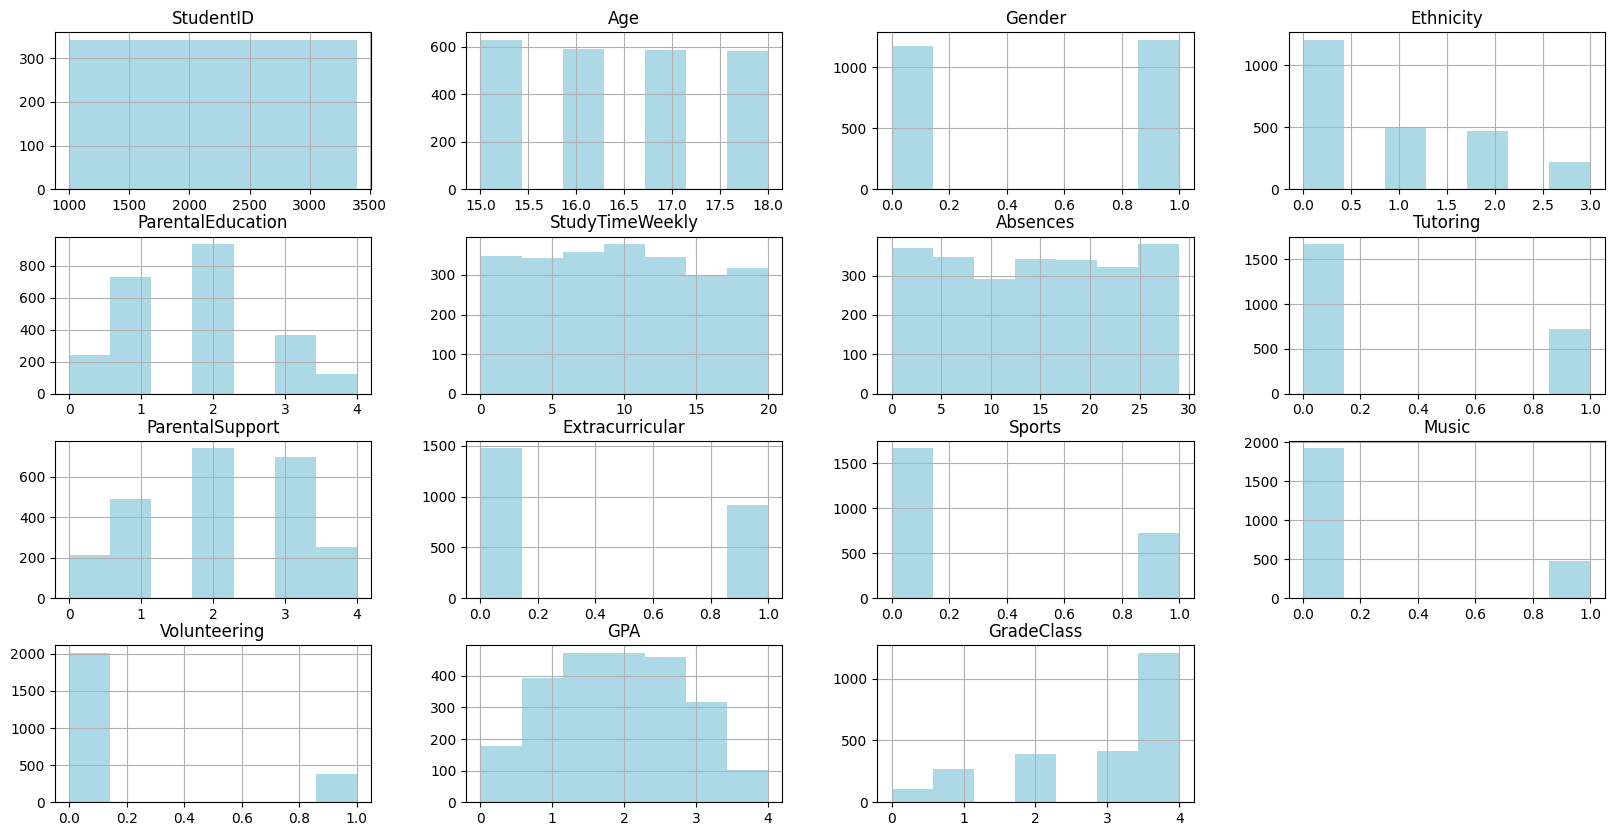

In [21]:
df.hist(figsize=(20,10),bins=7, color='lightblue')

In [22]:
# Distinction is based on the number of different values in the column
columns = list(df.columns)

categoric_columns = []
numeric_columns = []

for i in columns:
    if len(df[i].unique()) > 5:
        numeric_columns.append(i)
    else:
        categoric_columns.append(i)
        
# Assuming the first column is an ID or non-numeric feature
numeric_columns = numeric_columns[1:]

print('Numerical features: ', numeric_columns)
print('Categorical features: ', categoric_columns)

Numerical features:  ['StudyTimeWeekly', 'Absences', 'GPA']
Categorical features:  ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']


In [23]:
df[numeric_columns] = df[numeric_columns].astype('float64')

# <span style="font-family: 'Chillax', cursive; font-size: 1.3em; font-weight: 500">Module 1 - Statistical Foundation</span>

In [43]:
# Module 1: Minimal preprocessing for selected variables
m1_df = df[['GPA', 'StudyTimeWeekly', 'Absences', 'ParentalEducation']].copy()
m1_df.columns = ['Score', 'StudyTime', 'Absences', 'ParentalEduNum']

print('Prepared columns:', m1_df.columns.tolist())
print(m1_df.head())


Prepared columns: ['Score', 'StudyTime', 'Absences', 'ParentalEduNum']
      Score  StudyTime  Absences  ParentalEduNum
0  2.929196  19.833723       7.0               2
1  3.042915  15.408756       0.0               1
2  0.112602   4.210570      26.0               3
3  2.054218  10.028829      14.0               3
4  1.288061   4.672495      17.0               2


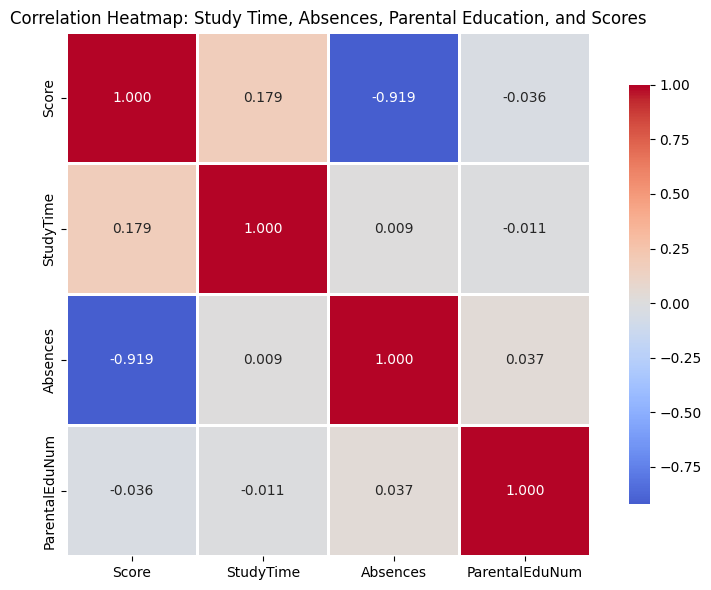

In [53]:
# Calculate correlation matrix
correlation_matrix = m1_df.corr()

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Study Time, Absences, Parental Education, and Scores')
plt.tight_layout()
plt.show()

In [57]:
from scipy import stats

# Perform one-way ANOVA comparing GPA scores across different GradeClass groups
grade_groups = [group['GPA'].values for name, group in df.groupby('GradeClass')]

f_statistic, p_value = stats.f_oneway(*grade_groups)

print(f"ANOVA Results: Comparing GPA across Grade Classes")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("\nResult: There is a statistically significant difference in GPA across grade classes (p < 0.05)")
else:
    print("\nResult: No statistically significant difference in GPA across grade classes (p >= 0.05)")

# Display summary statistics by grade class
print("\n" + "="*60)
print("Summary Statistics by Grade Class:")
print("="*60)
print(df.groupby('GradeClass')['GPA'].describe())

ANOVA Results: Comparing GPA across Grade Classes
F-statistic: 1174.8654
P-value: 0.0000e+00

Result: There is a statistically significant difference in GPA across grade classes (p < 0.05)

Summary Statistics by Grade Class:
             count      mean       std       min       25%       50%  \
GradeClass                                                             
0.0          107.0  3.102942  0.946137  0.214570  2.562795  3.548460   
1.0          269.0  3.001673  0.630402  0.000000  3.055254  3.167455   
2.0          391.0  2.659742  0.378969  0.557549  2.590990  2.712230   
3.0          414.0  2.215545  0.361295  0.000000  2.122740  2.238196   
4.0         1211.0  1.208041  0.547875  0.000000  0.816809  1.247482   

                 75%       max  
GradeClass                      
0.0         3.694455  4.000000  
1.0         3.332789  3.572945  
2.0         2.851936  3.597766  
3.0         2.377751  4.000000  
4.0         1.626695  3.979421  


In [58]:
from scipy.stats import pearsonr, spearmanr

# Compute Pearson correlation
pearson = m1_df.corr(method='pearson')

# Compute Spearman correlation
spearman = m1_df.corr(method='spearman')

print("Pearson Correlation Matrix:")
print(pearson)
print("\n" + "="*60 + "\n")
print("Spearman Correlation Matrix:")
print(spearman)

Pearson Correlation Matrix:
                   Score  StudyTime  Absences  ParentalEduNum
Score           1.000000   0.179275 -0.919314       -0.035854
StudyTime       0.179275   1.000000  0.009326       -0.011051
Absences       -0.919314   0.009326  1.000000        0.036518
ParentalEduNum -0.035854  -0.011051  0.036518        1.000000


Spearman Correlation Matrix:
                   Score  StudyTime  Absences  ParentalEduNum
Score           1.000000   0.169082 -0.925467       -0.034648
StudyTime       0.169082   1.000000  0.009184       -0.011402
Absences       -0.925467   0.009184  1.000000        0.035212
ParentalEduNum -0.034648  -0.011402  0.035212        1.000000


Pearson correlation:
  r = 0.1793, p-value = 1.0002e-18, n = 2392

Linear regression (Score ~ StudyTime):
  slope = 0.0290, intercept = 1.6226
  slope p-value = 1.0002e-18, R^2 = 0.0321

Conclusion:
  Reject H0: Study hours have a statistically significant linear impact on scores.


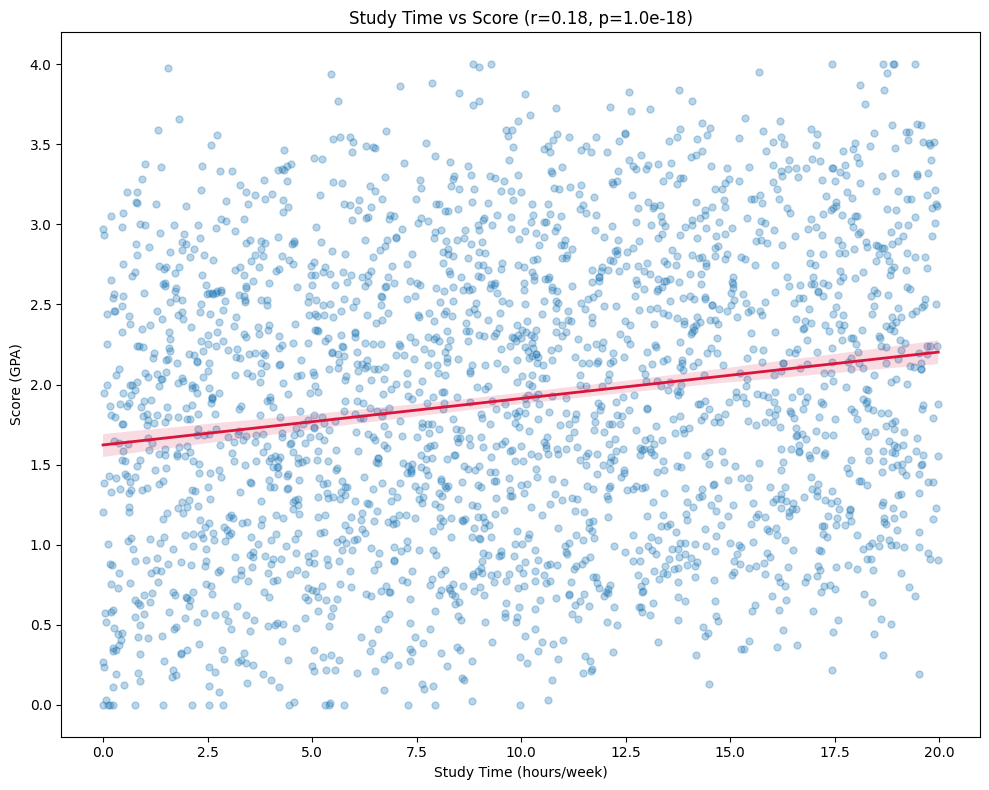

In [60]:
# Hypothesis test: Do study hours (StudyTime) significantly impact scores (Score)?

# Pearson correlation test (H0: no linear association)
r, p = pearsonr(m1_df['StudyTime'], m1_df['Score'])

# Simple linear regression (tests slope == 0)
lr = stats.linregress(m1_df['StudyTime'], m1_df['Score'])

print("Pearson correlation:")
print(f"  r = {r:.4f}, p-value = {p:.4e}, n = {len(m1_df)}")
print("\nLinear regression (Score ~ StudyTime):")
print(f"  slope = {lr.slope:.4f}, intercept = {lr.intercept:.4f}")
print(f"  slope p-value = {lr.pvalue:.4e}, R^2 = {lr.rvalue**2:.4f}")

alpha = 0.05
print("\nConclusion:")
if p < alpha and lr.pvalue < alpha:
    print("  Reject H0: Study hours have a statistically significant linear impact on scores.")
else:
    print("  Fail to reject H0: No statistically significant linear impact detected at alpha = 0.05.")

# Visualization
plt.figure(figsize=(10,8))
ax_study = sns.regplot(x='StudyTime', y='Score', data=m1_df,
                       scatter_kws={'alpha':0.3, 's':25},
                       line_kws={'color':'crimson', 'lw':2})
ax_study.set_title(f'Study Time vs Score (r={r:.2f}, p={p:.1e})')
ax_study.set_xlabel('Study Time (hours/week)')
ax_study.set_ylabel('Score (GPA)')
plt.tight_layout()
plt.show()

# <span style="font-family: 'Chillax', cursive; font-size: 1.3em; font-weight: 500">Module 2 - Data Handling</span>

In [61]:
# Module 2: Handle missing data in Family background features

# Check for missing values in the dataset
print("Missing values in dataset:")
print(df.isnull().sum())
print("\n" + "="*60 + "\n")

# Family background features
family_features = ['ParentalEducation', 'ParentalSupport']

print("Missing values in family background features:")
for feature in family_features:
    missing_count = df[feature].isnull().sum()
    missing_pct = (missing_count / len(df)) * 100
    print(f"  {feature}: {missing_count} ({missing_pct:.2f}%)")

# Handle missing values
# Since these are categorical/ordinal variables, we'll use mode (most frequent value) imputation
if df[family_features].isnull().sum().sum() > 0:
    print("\n" + "="*60)
    print("Handling missing values...")
    
    for feature in family_features:
        if df[feature].isnull().sum() > 0:
            mode_value = df[feature].mode()[0]
            df[feature].fillna(mode_value, inplace=True)
            print(f"  {feature}: Filled {df[feature].isnull().sum()} missing values with mode = {mode_value}")
    
    print("\nAfter handling missing values:")
    print(df[family_features].isnull().sum())
else:
    print("\nNo missing values found in family background features!")

Missing values in dataset:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


Missing values in family background features:
  ParentalEducation: 0 (0.00%)
  ParentalSupport: 0 (0.00%)

No missing values found in family background features!


In [69]:
# One-hot encode requested categorical variables if present (with sensible column name mapping)
requested = ['school', 'sex', 'address', 'family size']
candidates = {
    'school': ['school', 'School'],
    'sex': ['sex', 'Sex', 'Gender', 'gender'],
    'address': ['address', 'Address'],
    'family size': ['famsize', 'fam_size', 'family_size', 'FamilySize', 'family size', 'Family Size'],
}

# Resolve actual columns in df
prefix_map = {}   # original_col -> desired prefix
present_cols = []
skipped = []

for key in requested:
    found = None
    for cand in candidates[key]:
        if cand in df.columns:
            found = cand
            break
    if found is not None:
        present_cols.append(found)
        prefix_map[found] = key.replace(' ', '_')
    else:
        skipped.append(key)

if present_cols:
    df_ohe = pd.get_dummies(
        df,
        columns=present_cols,
        prefix=prefix_map,
        dtype=int
    )
    print("One-hot encoded columns:", present_cols)
    if skipped:
        print("Requested but not found (skipped):", skipped)
    # Show newly created dummy columns
    new_dummy_cols = [c for orig, pref in prefix_map.items() for c in df_ohe.columns if c.startswith(pref + "_")]
    print("Created dummy columns:", new_dummy_cols[:20], "..." if len(new_dummy_cols) > 20 else "")
else:
    df_ohe = df.copy()
    print("No requested columns found to one-hot encode. Skipped:", skipped)
df_ohe = df_ohe.rename(columns={'sex_0': 'Male', 'sex_1': 'Female'})
df_ohe.head()

One-hot encoded columns: ['Gender']
Requested but not found (skipped): ['school', 'address', 'family size']
Created dummy columns: ['sex_0', 'sex_1'] 


,StudentID,Age,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,Male,Female
0,1001,17,0,2,19.833723,7.0,1,2,0,0,1,0,2.929196,2.0,0,1
1,1002,18,0,1,15.408756,0.0,0,1,0,0,0,0,3.042915,1.0,1,0
2,1003,15,2,3,4.210570,26.0,0,2,0,0,0,0,0.112602,4.0,1,0
3,1004,17,0,3,10.028829,14.0,0,3,1,0,0,0,2.054218,3.0,0,1
4,1005,17,0,2,4.672495,17.0,1,3,0,0,0,0,1.288061,4.0,0,1


In [70]:
from sklearn.preprocessing import StandardScaler

# Module 2: Normalize numeric features (age, study time, failures)

# Identify the features to normalize
# Based on the dataset, we have:
# - Age (already present)
# - StudyTimeWeekly (study time)
# - Absences (could be considered as "failures" or we'll add it as well)

normalize_features = ['Age', 'StudyTimeWeekly', 'Absences']

# Create a copy of df_ohe to preserve original data
df_normalized = df_ohe.copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Normalize the selected features
df_normalized[normalize_features] = scaler.fit_transform(df_ohe[normalize_features])

print("Normalized features:", normalize_features)
print("\nOriginal statistics:")
print(df_ohe[normalize_features].describe())
print("\n" + "="*60)
print("\nNormalized statistics (mean ≈ 0, std ≈ 1):")
print(df_normalized[normalize_features].describe())
print("\nFirst few rows of normalized data:")
print(df_normalized[normalize_features].head(10))

Normalized features: ['Age', 'StudyTimeWeekly', 'Absences']

Original statistics:
               Age  StudyTimeWeekly     Absences
count  2392.000000      2392.000000  2392.000000
mean     16.468645         9.771992    14.541388
std       1.123798         5.652774     8.467417
min      15.000000         0.001057     0.000000
25%      15.000000         5.043079     7.000000
50%      16.000000         9.705363    15.000000
75%      17.000000        14.408410    22.000000
max      18.000000        19.978094    29.000000


Normalized statistics (mean ≈ 0, std ≈ 1):
                Age  StudyTimeWeekly      Absences
count  2.392000e+03     2.392000e+03  2.392000e+03
mean   8.406505e-16     1.173346e-16  8.911489e-18
std    1.000209e+00     1.000209e+00  1.000209e+00
min   -1.307132e+00    -1.728882e+00 -1.717694e+00
25%   -1.307132e+00    -8.367399e-01 -8.908224e-01
50%   -4.171064e-01    -1.178937e-02  5.417330e-02
75%    4.729190e-01     8.203737e-01  8.810445e-01
max    1.362944e+00     

In [73]:
# Module 2: Feature Engineering

# Create engineered features
df_engineered = df_normalized.copy()

# 1. total_study_time: Combination of StudyTimeWeekly (already normalized)
#    This feature represents the total study engagement
df_engineered['total_study_time'] = df_engineered['StudyTimeWeekly']

# 2. parent_education_level: Using ParentalEducation as a feature
#    (already present in the dataset, no transformation needed)
df_engineered['parent_education_level'] = df_engineered['ParentalEducation']

# 3. support_score: Composite score from ParentalSupport, Tutoring, and Extracurricular
#    This represents overall support system for the student
df_engineered['support_score'] = (
    df_engineered['ParentalSupport'] + 
    df_engineered['Tutoring'] + 
    df_engineered['Extracurricular']
)

print("Newly engineered features:")
print("  - total_study_time: normalized study hours per week")
print("  - parent_education_level: parental education level")
print("  - support_score: combined support from parents, tutoring, and extracurriculars")

print("\nFeature statistics:")
print(df_engineered[['total_study_time', 'parent_education_level', 'support_score']].describe())

print("\nFirst few rows of engineered features:")
print(df_engineered[['StudentID', 'total_study_time', 'parent_education_level', 'support_score', 'GPA']].head(10))

Newly engineered features:
  - total_study_time: normalized study hours per week
  - parent_education_level: parental education level
  - support_score: combined support from parents, tutoring, and extracurriculars

Feature statistics:
       total_study_time  parent_education_level  support_score
count      2.392000e+03             2392.000000    2392.000000
mean       1.173346e-16                1.746237       2.806856
std        1.000209e+00                1.000411       1.303851
min       -1.728882e+00                0.000000       0.000000
25%       -8.367399e-01                1.000000       2.000000
50%       -1.178937e-02                2.000000       3.000000
75%        8.203737e-01                2.000000       4.000000
max        1.805881e+00                4.000000       6.000000

First few rows of engineered features:
   StudentID  total_study_time  parent_education_level  support_score  \
0       1001          1.780336                       2              3   
1       100

In [77]:
# Module 2: Create interaction term - study_time × internet_access

# Since we don't have an explicit internet_access column, let's create a proxy
# We'll assume students with higher parental support are more likely to have internet access
# Creating a binary feature where ParentalSupport >= 3 indicates internet access

df_engineered['internet_access'] = (df_engineered['ParentalSupport'] >= 3).astype(int)

# Create the interaction term: study_time × internet_access
df_engineered['study_internet_interaction'] = (
    df_engineered['total_study_time'] * df_engineered['internet_access']
)

print("Created interaction feature:")
print("  - internet_access: binary proxy based on ParentalSupport >= 3")
print("  - study_internet_interaction: total_study_time × internet_access")

print("\nInternet access distribution:")
print(df_engineered['internet_access'].value_counts())

print("\nInteraction term statistics:")
print(df_engineered['study_internet_interaction'].describe())

print("\nSample of new features:")
print(df_engineered[['StudentID', 'total_study_time', 'ParentalSupport', 
                      'internet_access', 'study_internet_interaction', 'GPA']].head(5))

Created interaction feature:
  - internet_access: binary proxy based on ParentalSupport >= 3
  - study_internet_interaction: total_study_time × internet_access

Internet access distribution:
internet_access
0    1441
1     951
Name: count, dtype: int64

Interaction term statistics:
count    2392.000000
mean        0.019075
std         0.630922
min        -1.728882
25%         0.000000
50%         0.000000
75%         0.000000
max         1.805881
Name: study_internet_interaction, dtype: float64

Sample of new features:
   StudentID  total_study_time  ParentalSupport  internet_access  \
0       1001          1.780336                2                0   
1       1002          0.997376                1                0   
2       1003         -0.984045                2                0   
3       1004          0.045445                3                1   
4       1005         -0.902311                3                1   

   study_internet_interaction       GPA  
0                    0.0

# <span style="font-family: 'Chillax', cursive; font-size: 1.3em; font-weight: 500">Module 3 - Supervised Learning</span>

In [79]:
# CHOOSE THE TARGET FEATURE HERE, IN THIS CASE IT IS 'GradeClass'
X = df.drop(columns=['GradeClass', 'GPA', 'StudentID', 'Age'])
y = df['GradeClass']

# Splitting the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Model Comparison Results:
                       Model      MAE     RMSE       R2
     Random Forest Regressor 0.508198 0.771044 0.607715
Ridge Regression (alpha=1.0) 0.584672 0.805014 0.572387
           Linear Regression 0.584669 0.805031 0.572369


Interpretation:
- Lower MAE/RMSE indicates better predictions
- Higher R² (closer to 1.0) indicates better model fit

Random Forest - Top 10 Feature Importances:
Absences             0.647011
StudyTimeWeekly      0.159662
ParentalSupport      0.053798
ParentalEducation    0.027659
Tutoring             0.024635
Ethnicity            0.023038
Extracurricular      0.016333
Sports               0.014790
Gender               0.012817
Music                0.010167
dtype: float64


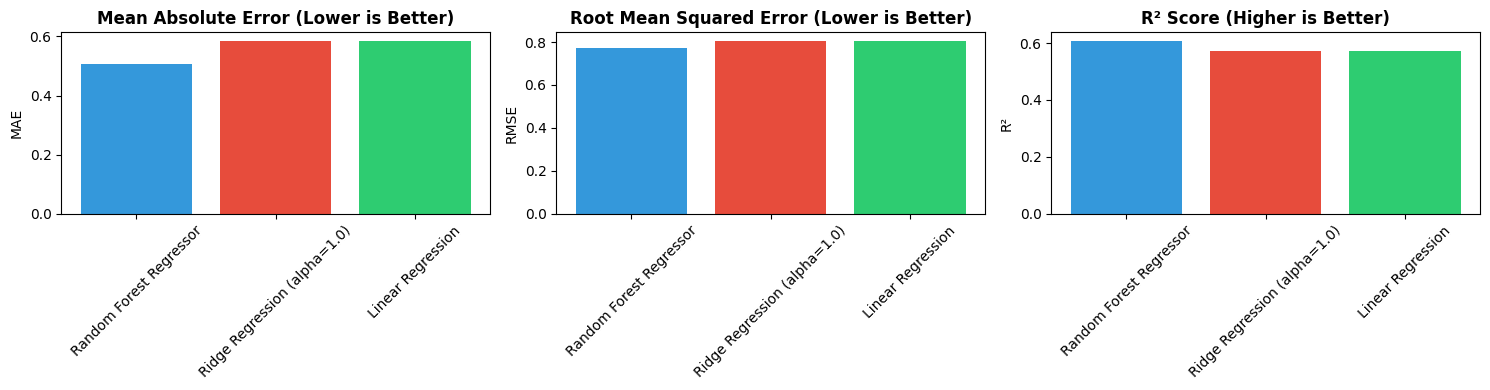

In [82]:
from sklearn.linear_model import Ridge

# Train and compare 3 models on (X_train, y_train) and evaluate on (X_test, y_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (alpha=1.0)": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)
print("Model Comparison Results:")
print("="*70)
print(results_df.to_string(index=False))
print("\n" + "="*70)
print("\nInterpretation:")
print("- Lower MAE/RMSE indicates better predictions")
print("- Higher R² (closer to 1.0) indicates better model fit")

# Show top feature importances for Random Forest
rf = models["Random Forest Regressor"]
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n" + "="*70)
print("Random Forest - Top 10 Feature Importances:")
print("="*70)
print(rf_importances.head(10))

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot MAE
axes[0].bar(results_df['Model'], results_df['MAE'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Mean Absolute Error (Lower is Better)', fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

# Plot RMSE
axes[1].bar(results_df['Model'], results_df['RMSE'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('Root Mean Squared Error (Lower is Better)', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

# Plot R²
axes[2].bar(results_df['Model'], results_df['R2'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 10-fold cross-validation for each model
print("10-Fold Cross-Validation Results:")
print("="*70)

cv_results = []

for name, model in models.items():
    # Perform 10-fold cross-validation
    # Using negative MSE as scoring metric (sklearn convention)
    cv_scores = cross_val_score(model, X_train, y_train, cv=10, 
                                scoring='neg_mean_squared_error', n_jobs=-1)
    
    # Convert negative MSE to RMSE
    cv_rmse = np.sqrt(-cv_scores)
    
    # Also get R² scores
    cv_r2 = cross_val_score(model, X_train, y_train, cv=10, 
                           scoring='r2', n_jobs=-1)
    
    cv_results.append({
        'Model': name,
        'Mean RMSE': cv_rmse.mean(),
        'Std RMSE': cv_rmse.std(),
        'Mean R²': cv_r2.mean(),
        'Std R²': cv_r2.std()
    })
    
    print(f"\n{name}:")
    print(f"  RMSE: {cv_rmse.mean():.4f} (±{cv_rmse.std():.4f})")
    print(f"  R²:   {cv_r2.mean():.4f} (±{cv_r2.std():.4f})")

cv_results_df = pd.DataFrame(cv_results).sort_values(by='Mean R²', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("Cross-Validation Summary:")
print("="*70)
print(cv_results_df.to_string(index=False))

print("\n" + "="*70)
print("Interpretation:")
print("- Lower Mean RMSE indicates better average prediction performance")
print("- Higher Mean R² indicates better model fit across all folds")
print("- Lower Std values indicate more consistent performance across folds")

10-Fold Cross-Validation Results:

Linear Regression:
  RMSE: 0.7927 (±0.0469)
  R²:   0.5849 (±0.0357)

Ridge Regression (alpha=1.0):
  RMSE: 0.7927 (±0.0469)
  R²:   0.5850 (±0.0356)

Random Forest Regressor:
  RMSE: 0.7504 (±0.0470)
  R²:   0.6280 (±0.0337)

Cross-Validation Summary:
                       Model  Mean RMSE  Std RMSE  Mean R²   Std R²
     Random Forest Regressor   0.750439  0.046951 0.627997 0.033719
Ridge Regression (alpha=1.0)   0.792687  0.046889 0.584950 0.035644
           Linear Regression   0.792693  0.046903 0.584943 0.035661


Interpretation:
- Lower Mean RMSE indicates better average prediction performance
- Higher Mean R² indicates better model fit across all folds
- Lower Std values indicate more consistent performance across folds


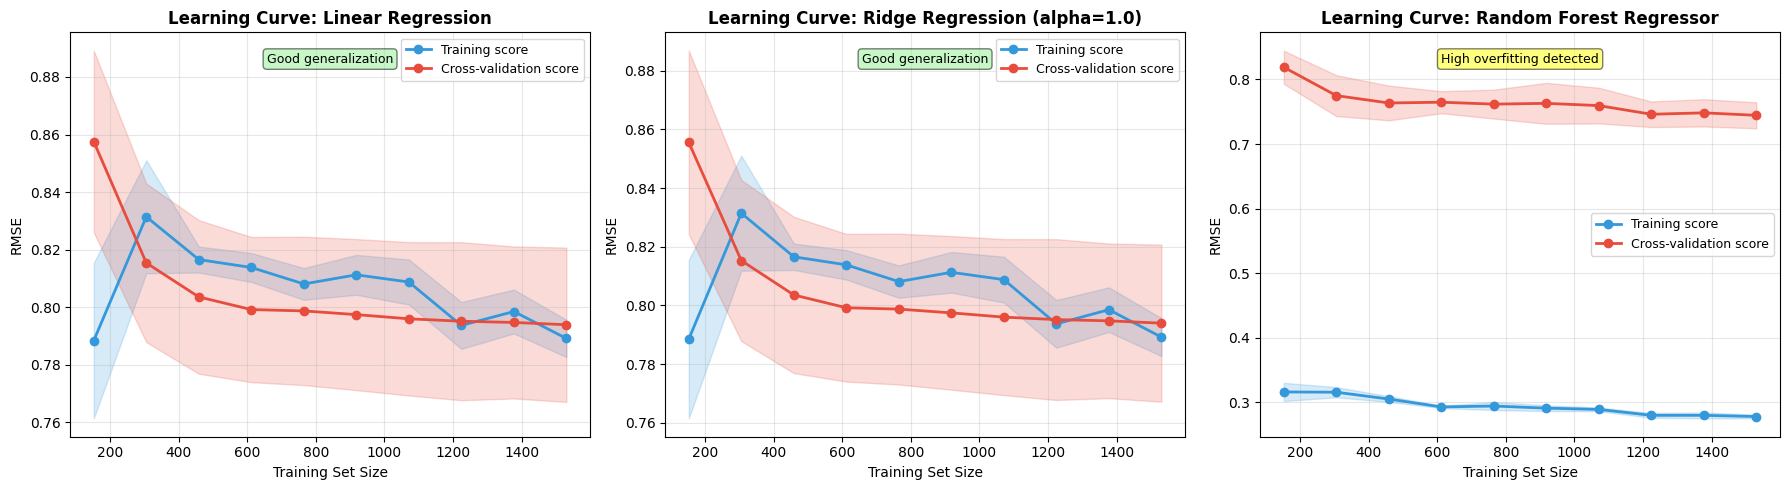


Learning Curve Interpretation:
- If training and validation curves converge: Good generalization
- If large gap between curves: Overfitting (model memorizes training data)
- If both curves have high error: Underfitting (model too simple)
- If curves are still improving: More data might help


In [85]:
from sklearn.model_selection import learning_curve

# Plot learning curves for the three models to detect overfitting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Compute learning curves
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, 
        cv=5, 
        scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        random_state=42
    )
    
    # Convert negative MSE to RMSE
    train_scores_mean = np.sqrt(-train_scores.mean(axis=1))
    train_scores_std = np.sqrt(-train_scores).std(axis=1)
    val_scores_mean = np.sqrt(-val_scores.mean(axis=1))
    val_scores_std = np.sqrt(-val_scores).std(axis=1)
    
    # Plot learning curves
    axes[idx].plot(train_sizes, train_scores_mean, 'o-', color='#3498db', 
                   label='Training score', linewidth=2, markersize=6)
    axes[idx].fill_between(train_sizes, 
                          train_scores_mean - train_scores_std,
                          train_scores_mean + train_scores_std, 
                          alpha=0.2, color='#3498db')
    
    axes[idx].plot(train_sizes, val_scores_mean, 'o-', color='#e74c3c', 
                   label='Cross-validation score', linewidth=2, markersize=6)
    axes[idx].fill_between(train_sizes, 
                          val_scores_mean - val_scores_std,
                          val_scores_mean + val_scores_std, 
                          alpha=0.2, color='#e74c3c')
    
    axes[idx].set_title(f'Learning Curve: {name}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Training Set Size', fontsize=10)
    axes[idx].set_ylabel('RMSE', fontsize=10)
    axes[idx].legend(loc='best', fontsize=9)
    axes[idx].grid(alpha=0.3)
    
    # Add overfitting interpretation
    final_gap = val_scores_mean[-1] - train_scores_mean[-1]
    if final_gap > 0.2:
        axes[idx].text(0.5, 0.95, 'High overfitting detected', 
                      transform=axes[idx].transAxes, 
                      ha='center', va='top', 
                      bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
                      fontsize=9)
    elif final_gap > 0.1:
        axes[idx].text(0.5, 0.95, 'Moderate overfitting', 
                      transform=axes[idx].transAxes, 
                      ha='center', va='top', 
                      bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5),
                      fontsize=9)
    else:
        axes[idx].text(0.5, 0.95, 'Good generalization', 
                      transform=axes[idx].transAxes, 
                      ha='center', va='top', 
                      bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5),
                      fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Learning Curve Interpretation:")
print("="*70)
print("- If training and validation curves converge: Good generalization")
print("- If large gap between curves: Overfitting (model memorizes training data)")
print("- If both curves have high error: Underfitting (model too simple)")
print("- If curves are still improving: More data might help")